In [5]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Annotated,Literal
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver 
## above memory saver is only for demo or learning in production we use different checkppointer like redis postgres


In [6]:
# from langchain_ollama import ChatOllama

# model = ChatOllama(
#     model="qwen3:4b",
#     temperature=0,
# )


from dotenv import load_dotenv


load_dotenv()
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-Coder-32B-Instruct",
    task="text-generation",
    max_new_tokens=512,
)

model = ChatHuggingFace(llm=llm)

In [7]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explaination:str

In [8]:


def generate_joke(state:JokeState):
    topic =  state['topic']
    prompt = f'generate a joke on the topic {topic} in less than 20 word not more than that'
    response = model.invoke(prompt)

    return {'joke':response}


In [9]:
def generate_explaination(state:JokeState):

    prompt = f"generate the explaination for the joke - {state['joke']}" 
    response =  model.invoke(prompt)

    return {'explaination':response}

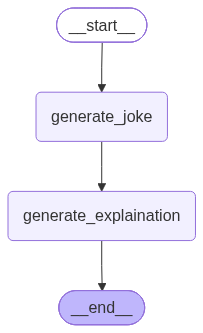

In [10]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explaination',generate_explaination)


## edges
graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explaination')
graph.add_edge('generate_explaination',END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [11]:
config1 = {'configurable':{"thread_id":"1"}}

workflow.invoke({'topic':"pasta"},config = config1)

{'topic': 'pasta',
 'joke': AIMessage(content='Why did the pasta go to therapy? Because it was feeling noodle-ly!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 47, 'total_tokens': 65}, 'model_name': 'Qwen/Qwen2.5-Coder-32B-Instruct', 'system_fingerprint': 'vllm-0.21.0-f5ee5085', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06ae4-8d6e-73b1-a4ad-e22ff2602d1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 18, 'total_tokens': 65}),
 'explaination': AIMessage(content='The joke plays on the word "noodle-ly," which is a playful twist on the feeling of being "tired" or "exhausted." In this context, "noodle-ly" is used humorously to suggest that the pasta is experiencing a form of fatigue or lack of energy, much like how one might say they feel "spaghetti-tired" or "fry-ly" in a similar light-hearted manner. The punchline introduces a clever pun by suggesting that due to its "noo

In [12]:
config2 = {'configurable':{"thread_id":"2"}}

workflow.invoke({'topic':"cricket"},config = config2)

{'topic': 'cricket',
 'joke': AIMessage(content='Why did the cricket player quit? Because he was constantly hearing "out"!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 47, 'total_tokens': 64}, 'model_name': 'Qwen/Qwen2.5-Coder-32B-Instruct', 'system_fingerprint': 'vllm-0.21.0-f5ee5085', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06ae4-b886-71a1-92a8-e3f405e17c1c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 17, 'total_tokens': 64}),
 'explaination': AIMessage(content='The joke plays on the double meaning of the word "out." In cricket, when a player is dismissed from play, it\'s called being "out." However, the word also has a common usage meaning to leave or quit something. The cricket player decides to quit because he kept hearing "out," which initially referred to his dismissals but could also mean that it was time for him to leave the game. This creates a humorous

In [13]:
workflow.get_state(config1)


StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content='Why did the pasta go to therapy? Because it was feeling noodle-ly!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 47, 'total_tokens': 65}, 'model_name': 'Qwen/Qwen2.5-Coder-32B-Instruct', 'system_fingerprint': 'vllm-0.21.0-f5ee5085', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06ae4-8d6e-73b1-a4ad-e22ff2602d1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 18, 'total_tokens': 65}), 'explaination': AIMessage(content='The joke plays on the word "noodle-ly," which is a playful twist on the feeling of being "tired" or "exhausted." In this context, "noodle-ly" is used humorously to suggest that the pasta is experiencing a form of fatigue or lack of energy, much like how one might say they feel "spaghetti-tired" or "fry-ly" in a similar light-hearted manner. The punchline introduces a clever pun by suggesting t

In [17]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content='Why did the pasta go to therapy? Because it was feeling noodle-ly!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 47, 'total_tokens': 65}, 'model_name': 'Qwen/Qwen2.5-Coder-32B-Instruct', 'system_fingerprint': 'vllm-0.21.0-f5ee5085', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06ae4-8d6e-73b1-a4ad-e22ff2602d1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 18, 'total_tokens': 65}), 'explaination': AIMessage(content='The joke plays on the word "noodle-ly," which is a playful twist on the feeling of being "tired" or "exhausted." In this context, "noodle-ly" is used humorously to suggest that the pasta is experiencing a form of fatigue or lack of energy, much like how one might say they feel "spaghetti-tired" or "fry-ly" in a similar light-hearted manner. The punchline introduces a clever pun by suggesting 

# Time Travel

In [18]:
# at what checkpoint we have to reiterate
workflow.get_state({'configurable':{'thread_id':"1","checkpoint_id":"1f1a8219-3552-6453-bfff-805c4eaac0fe"}})

StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1a8219-3552-6453-bfff-805c4eaac0fe'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-09-04T05:29:18.441377+00:00', parent_config=None, tasks=(PregelTask(id='3bbcb7ef-8f0a-90c6-1c0f-b6a281e7fdf0', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'topic': 'pasta'}),), interrupts=())

In [19]:
## we have to invoke from that checkpoint and invoke from that checkpoint
workflow.invoke(None,{"configurable": {"thread_id":"1", "checkpoint_id":"1f1a8219-3552-6453-bfff-805c4eaac0fe"}})

{'topic': 'pasta',
 'joke': AIMessage(content='Why did the pasta go to the doctor? Because it felt a little saucy!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 47, 'total_tokens': 66}, 'model_name': 'Qwen/Qwen2.5-Coder-32B-Instruct', 'system_fingerprint': 'vllm-0.21.0-f5ee5085', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06ae6-a925-71e2-9005-0d095dfeaa0b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 19, 'total_tokens': 66}),
 'explaination': AIMessage(content='The joke plays on the double meaning of the word "saucy." In the context of food, "sauce" is something that accompanies pasta, making it flavorful and often spicy. However, "saucy" can also mean lively, impudent, or sexually provocative. The punchline, "Because it felt a little saucy!" humorously suggests that the pasta is experiencing a feeling similar to someone who might be acting in a bold or flirtatious ma

In [20]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content='Why did the pasta go to the doctor? Because it felt a little saucy!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 47, 'total_tokens': 66}, 'model_name': 'Qwen/Qwen2.5-Coder-32B-Instruct', 'system_fingerprint': 'vllm-0.21.0-f5ee5085', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06ae6-a925-71e2-9005-0d095dfeaa0b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 19, 'total_tokens': 66}), 'explaination': AIMessage(content='The joke plays on the double meaning of the word "saucy." In the context of food, "sauce" is something that accompanies pasta, making it flavorful and often spicy. However, "saucy" can also mean lively, impudent, or sexually provocative. The punchline, "Because it felt a little saucy!" humorously suggests that the pasta is experiencing a feeling similar to someone who might be acting in a bo

# Update State

In [21]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1a8219-3552-6453-bfff-805c4eaac0fe", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a821f-0b1f-60dc-8000-41fae83a5414'}}

In [22]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a821f-0b1f-60dc-8000-41fae83a5414'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-09-04T05:31:55.077654+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a8219-3552-6453-bfff-805c4eaac0fe'}}, tasks=(PregelTask(id='68b53a7a-8ed2-05fd-8512-24ea6b4a1bfb', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content='Why did the pasta go to the doctor? Because it felt a little saucy!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 47, 'total_tokens': 66}, 'model_name': 'Qwen/Qwen2.5-Coder-32B-Instruct', 'system_fingerprint': 'vllm-0.21.0-f5ee5085', 'finish_reason': 'stop'

In [23]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1a821f-0b1f-60dc-8000-41fae83a5414"}})

{'topic': 'samosa',
 'joke': AIMessage(content="Why did the samosa go to therapy? Because it couldn't stop folding over itself!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 48, 'total_tokens': 67}, 'model_name': 'Qwen/Qwen2.5-Coder-32B-Instruct', 'system_fingerprint': 'vllm-0.21.0-f5ee5085', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06ae7-341a-7ee2-8097-3da9ae3e2cd6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 19, 'total_tokens': 67}),
 'explaination': AIMessage(content='The joke is a play on words and a pun involving the concept of "folding" as it relates to both a psychological state (as in folding under pressure or stress) and the physical shape of a samosa. Here\'s the explanation:\n\n1. **Pun on "Folding"**: \n   - Samosas are typically crescent-shaped or triangular, which involves folding dough.\n   - In psychology, "folding over oneself" is an idiomatic expr

In [24]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': AIMessage(content="Why did the samosa go to therapy? Because it couldn't stop folding over itself!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 48, 'total_tokens': 67}, 'model_name': 'Qwen/Qwen2.5-Coder-32B-Instruct', 'system_fingerprint': 'vllm-0.21.0-f5ee5085', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06ae7-341a-7ee2-8097-3da9ae3e2cd6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 19, 'total_tokens': 67}), 'explaination': AIMessage(content='The joke is a play on words and a pun involving the concept of "folding" as it relates to both a psychological state (as in folding under pressure or stress) and the physical shape of a samosa. Here\'s the explanation:\n\n1. **Pun on "Folding"**: \n   - Samosas are typically crescent-shaped or triangular, which involves folding dough.\n   - In psychology, "folding over oneself" 

# Fault Tolerance

In [2]:

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [3]:

# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [4]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [5]:

# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:

try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


In [6]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...


EmptyInputError: Received no input for __start__